# Making Carbonate Sensitivies for ROMS-MARBL-LiTE
This notebook demonstrates how to make the carbonate sensitivies `eta` and `beta`, needed when running `ROMS` with `MARBL-Lite` (see background on FEATURES_PAGE). Rather than running the full biogeochemical model `MARBL`, `MARBL-LiTE` requires only a timeseries of the `eta` and `beta` fields. Where,
- ``eta  = dDIC / dALK``
- ``beta = dDIC / dCO2``
  
To calculate `eta` and `beta`, the `bgc` and `his` files are needed from a previous run of `ROMS-MARBL`. The variables collected from these files are `temp` and `salt` from the `his` files, and `ALK_ALT_CO2`, `DIC_ALT_CO2`, `salt`, `temp`, `PO4`, `SiO3` from the `bgc` files. 

**Note:** the frequency of output of your `bgc` and `his` records will determine how frequently your `eta` and `beta` fields are updated in a `ROMS-MARBL-LiTE` simulation. In this example we use daily. 

In [2]:
from roms_tools import Grid, calculate_eta_beta

In [3]:
%%time 
grid = Grid(filename="/Users/sam.maticka/workdir/CDR-Tracer-ROMS/files_testing/smaller/Iceland3_grid.nc")

fields = calculate_eta_beta(
    grid=grid,
    his_path="/Users/sam.maticka/workdir/CDR-Tracer-ROMS/files_testing/reduced/*his*",
    bgc_path="//Users/sam.maticka/workdir/CDR-Tracer-ROMS/files_testing/reduced/*bgc*",
)

2026-09-24 10:32:51 - INFO - Variables taken from his files: ['temp', 'salt', 'ocean_time']
2026-09-24 10:33:05 - INFO - Variables taken from bgc files: ['ALK_ALT_CO2', 'DIC_ALT_CO2', 'PO4', 'SiO3', 'ocean_time']


CPU times: user 26.5 s, sys: 17 s, total: 43.5 s
Wall time: 47.6 s


In [4]:
fields.ds_surface_control

<xarray.Dataset> Size: 143MB
Dimensions:      (time: 24, eta_rho: 386, xi_rho: 642)
Dimensions without coordinates: time, eta_rho, xi_rho
Data variables:
    temp         (time, eta_rho, xi_rho) float32 24MB 11.43 11.43 ... -0.0 0.0
    salt         (time, eta_rho, xi_rho) float32 24MB 34.84 34.84 ... 0.0 0.0
    ocean_time   (time) float64 192B 7.739e+08 7.739e+08 ... 7.74e+08 7.74e+08
    ALK_ALT_CO2  (time, eta_rho, xi_rho) float32 24MB 2.302e+03 ... 0.0
    DIC_ALT_CO2  (time, eta_rho, xi_rho) float32 24MB 2.078e+03 ... 0.0
    PO4          (time, eta_rho, xi_rho) float32 24MB 0.6708 0.6715 ... 0.0 0.0
    SiO3         (time, eta_rho, xi_rho) float32 24MB 6.645 6.644 ... 0.0 0.0
Attributes: (12/44)
    global_x:           640
    global_y:           384
    title:                        Iceland3_MARBL_2024 , 50 m  resolution
    grid_file:          /anvil/scratch/x-uheede/Iceland3_MARBL_2024/P_INPUT/I...
    forcing_files:       /anvil/scratch/x-uheede/Iceland3_MARBL_2024/P_INPUT/...
    forcing_info:       
    ...                 ...
    tide_options:       OFF
    river_frc_options:  OFF
    pipe_frc_options:   OFF
    particle_options:   OFF
    git_version:        xxx
    type:               ROMS history file

In [5]:
fields.ds

<xarray.Dataset> Size: 99MB
Dimensions:     (time: 24, eta_rho: 386, xi_rho: 642)
Coordinates:
    lat_rho     (eta_rho, xi_rho) float64 2MB 64.24 64.24 64.24 ... 64.41 64.41
    lon_rho     (eta_rho, xi_rho) float64 2MB 338.0 338.0 338.0 ... 338.7 338.7
    ocean_time  (time) float64 192B 7.739e+08 7.739e+08 ... 7.74e+08 7.74e+08
    abs_time    (time) datetime64[ns] 192B 2024-07-10T12:00:00 ... 2024-07-11...
Dimensions without coordinates: time, eta_rho, xi_rho
Data variables:
    eta         (time, eta_rho, xi_rho) float64 48MB 0.8536 0.8536 ... nan nan
    beta        (time, eta_rho, xi_rho) float64 48MB 12.87 12.86 ... nan nan

In [8]:
tind=23

min, max: 0.852062057229332, 0.9320934813207865


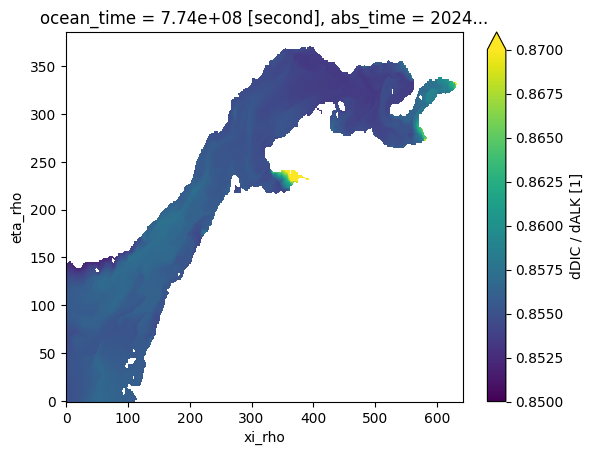

In [9]:
fields.ds.isel({"time":tind})["eta"].plot(vmin=0.85, vmax=0.87);
print(f'min, max: {fields.ds.isel({"time":tind})["eta"].min().values}, {fields.ds.isel({"time":tind})["eta"].max().values}')